In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split

import seaborn as sns

from statsmodels.tsa.stattools import adfuller
sns.set_style('whitegrid')  #style list >  'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import acf

import itertools
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error
from scipy.special import inv_boxcox  # Perbaiki impor di sini
from scipy.stats import boxcox

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Dataset atau Handson\store5.csv")

In [3]:
df

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57


Beverages Product

In [4]:
df_beverages = df[df["family"] == "BEVERAGES"]
df_beverages

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN
36,3237,2013-01-02,5,BEVERAGES,947.0,0,93.14
69,5019,2013-01-03,5,BEVERAGES,847.0,0,92.97
102,6801,2013-01-04,5,BEVERAGES,859.0,0,93.12
135,8583,2013-01-05,5,BEVERAGES,912.0,0,NaN
...,...,...,...,...,...,...,...
55410,2993433,2017-08-11,5,BEVERAGES,1717.0,11,48.81
55443,2995215,2017-08-12,5,BEVERAGES,1353.0,6,NaN
55476,2996997,2017-08-13,5,BEVERAGES,1838.0,9,NaN
55509,2998779,2017-08-14,5,BEVERAGES,1771.0,10,47.59


Checking Missing date

In [5]:
df_beverages['date'] = pd.to_datetime(df_beverages['date'])

full_date_range = pd.date_range(start=df_beverages['date'].min(), end=df_beverages['date'].max(), freq='D')

missing_dates = full_date_range.difference(df_beverages['date'])
missing_dates_count = missing_dates.size

missing_dates

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9520\592962151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_beverages['date'] = pd.to_datetime(df_beverages['date'])


DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

Adding Date and fill the data with 0 in sales and onpromotion

In [6]:
df_beverages = df_beverages.set_index('date').reindex(full_date_range).reset_index()

df_beverages.rename(columns = {'index' : 'date'}, inplace= True)

df_beverages[['sales' , 'onpromotion']] = df_beverages[['sales' , 'onpromotion']].fillna(0)

df_beverages['store_nbr'] = df_beverages['store_nbr'].fillna(5).astype(int)
df_beverages['family'] = df_beverages['family'].fillna("BEVERAGES")

Handling Missing Value

In [17]:
df_beverages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1688 non-null   datetime64[ns]
 1   id           1684 non-null   float64       
 2   store_nbr    1688 non-null   int32         
 3   family       1688 non-null   object        
 4   sales        1688 non-null   float64       
 5   onpromotion  1688 non-null   float64       
 6   dcoilwtico   1163 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int32(1), object(1)
memory usage: 85.8+ KB


Comparing the distribution of sales data with WTI Oil Prices

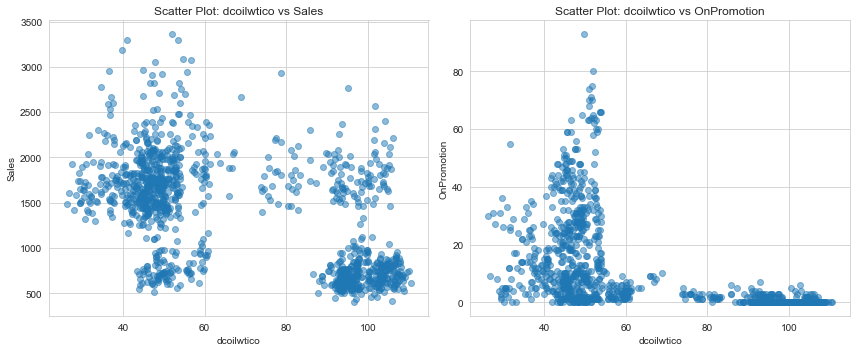

In [8]:
# Scatter plot dcoilwtico vs sales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_beverages["dcoilwtico"], df_beverages["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("Sales")
plt.title("Scatter Plot: dcoilwtico vs Sales")

# Scatter plot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_beverages["dcoilwtico"], df_beverages["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("OnPromotion")
plt.title("Scatter Plot: dcoilwtico vs OnPromotion")

plt.tight_layout()
plt.show()

non-linear distribution of oil price comparison with sales and promotion, then using polymonial interpolation to fill Missing Value

In [7]:
#Polymonial Interpolation
df_beverages['dcoilwtico_interpolate'] = df_beverages['dcoilwtico'].interpolate(method='polynomial', order=2)

# Fill missing values using backward fill
df_beverages['dcoilwtico_interpolate'] = df_beverages['dcoilwtico_interpolate'].fillna(method='bfill')

In [8]:
df_beverages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    1688 non-null   datetime64[ns]
 1   id                      1684 non-null   float64       
 2   store_nbr               1688 non-null   int32         
 3   family                  1688 non-null   object        
 4   sales                   1688 non-null   float64       
 5   onpromotion             1688 non-null   float64       
 6   dcoilwtico              1163 non-null   float64       
 7   dcoilwtico_interpolate  1688 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int32(1), object(1)
memory usage: 99.0+ KB


Comparing data after Interpolate and Backward Fill

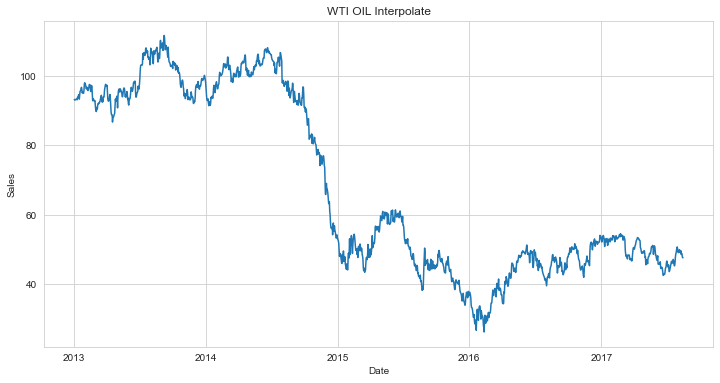

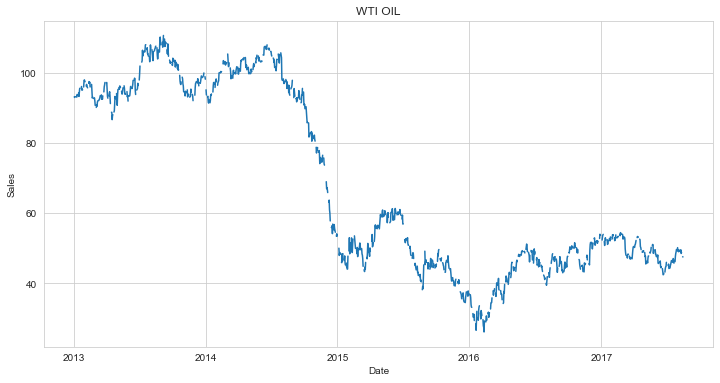

In [13]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(df_beverages['date'], df_beverages['dcoilwtico_interpolate'])
plt.title('WTI OIL Interpolate')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)

plt.figure(figsize=(12, 6))
plt.plot(df_beverages['date'], df_beverages['dcoilwtico'])
plt.title('WTI OIL')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [ ]:
df_beverages = df_beverages.drop(['dcoilwtico', 'id'], axis=1)

Check Stationary

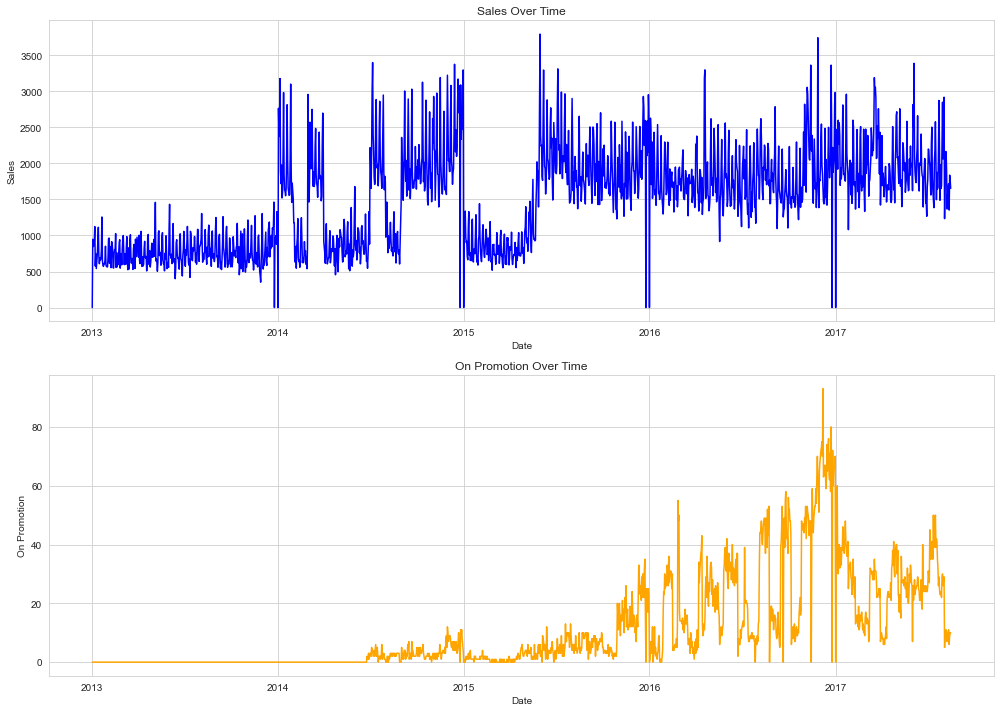

In [12]:
#based on Plot

plt.figure(figsize=(14, 10), facecolor='white')

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(df_beverages['date'], df_beverages['sales'], color='blue')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion
plt.subplot(2, 1, 2)
plt.plot(df_beverages['date'], df_beverages['onpromotion'], color='orange')
plt.title("On Promotion Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

plt.tight_layout()
plt.show()

ADF test

In [12]:
columns_to_test = df_beverages[['sales', 'onpromotion', 'dcoilwtico_interpolate']]

# Perform ADF test on each column
for column in columns_to_test:
    result = adfuller(df_beverages[column])
    print(f'Results of ADF Test for {column}:')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] < 0.05:
        print(f"The {column} series is stationary.")
    else:
        print(f"The {column} series is non-stationary.")
    print('\n')

Results of ADF Test for sales:
ADF Statistic: -3.9271461204218965
p-value: 0.0018439053663141499
Critical Values: {'1%': -3.434283579780684, '5%': -2.863277451883613, '10%': -2.5676949772294817}
The sales series is stationary.


Results of ADF Test for onpromotion:
ADF Statistic: -2.3538523951515486
p-value: 0.1551868895677349
Critical Values: {'1%': -3.4342906911169404, '5%': -2.8632805908715726, '10%': -2.5676966486957706}
The onpromotion series is non-stationary.


Results of ADF Test for dcoilwtico_interpolate:
ADF Statistic: -0.8749221798951536
p-value: 0.7961186979372235
Critical Values: {'1%': -3.4342368189880146, '5%': -2.8632568111941152, '10%': -2.5676839863871304}
The dcoilwtico_interpolate series is non-stationary.




Transforming onpromotion with boxcot to make it stationary

In [9]:
#differencing

df_beverages['dcoilwtico_interpolate_differenced'] = df_beverages['dcoilwtico_interpolate'].diff()

#boxcot

df_beverages['onpromotion_boxcox'], lambda_bc = boxcox(df_beverages['onpromotion'] + 1)

# Drop the NaN value created by differencing
df_beverages = df_beverages.dropna()

Checking Seasonal Pattern onpromotion

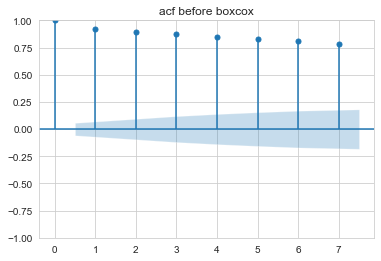

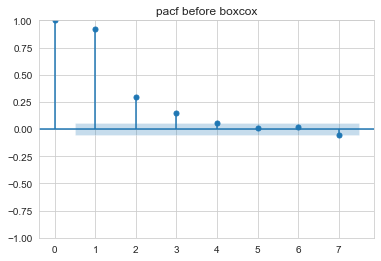

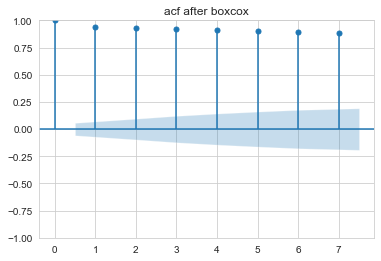

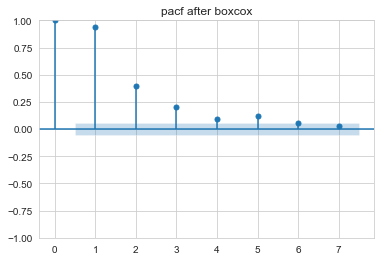

In [12]:
plot_acf(df_beverages['onpromotion'], lags = 7)
plt.title('acf before boxcox')

plot_pacf(df_beverages['onpromotion'], lags = 7)
plt.title('pacf before boxcox')
plt.show()

plot_acf(df_beverages['onpromotion_boxcox'], lags = 7)
plt.title('acf after boxcox')

plot_pacf(df_beverages['onpromotion_boxcox'], lags = 7)
plt.title('pacf after boxcox')

plt.show()

C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


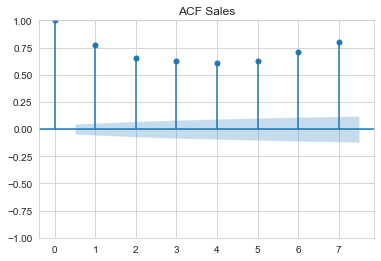

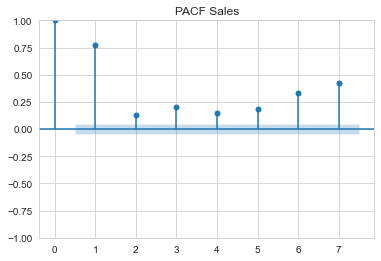

In [30]:
plot_acf(df_beverages['sales'], lags = 7)
plt.title('ACF Sales')

plot_pacf(df_beverages['sales'], lags = 7)
plt.title('PACF Sales')
plt.show()

C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


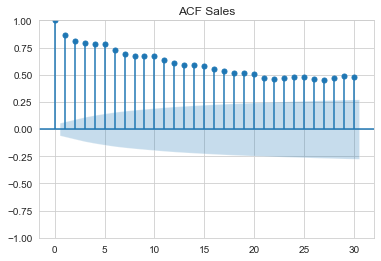

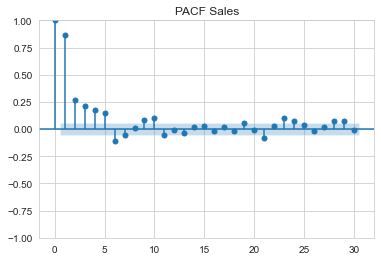

In [58]:
plot_acf(df_beverages['sales'], lags = 30)
plt.title('ACF Sales')

plot_pacf(df_beverages['sales'], lags = 30)
plt.title('PACF Sales')
plt.show()

Based on ACF and ADF, there are no seasonal pattern

# Modeling

In [68]:
df_beverages

,store_nbr,family,sales,onpromotion,dcoilwtico_interpolate,onpromotion_differenced
date,,,,,,
2013-01-02,5,BEVERAGES,947.0,0.0,93.140000,0.0
2013-01-03,5,BEVERAGES,847.0,0.0,92.970000,0.0
2013-01-04,5,BEVERAGES,859.0,0.0,93.120000,0.0
2013-01-05,5,BEVERAGES,912.0,0.0,93.205338,0.0
2013-01-06,5,BEVERAGES,1124.0,0.0,93.185272,0.0
...,...,...,...,...,...,...
2017-08-11,5,BEVERAGES,1717.0,11.0,48.810000,1.0
2017-08-12,5,BEVERAGES,1353.0,6.0,48.717426,-5.0
2017-08-13,5,BEVERAGES,1838.0,9.0,48.020802,3.0


In [52]:
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error

df_beverages['date'] = pd.to_datetime(df_beverages['date'])

df_beverages.set_index('date', inplace=True)

endog = df_beverages[['sales', 'onpromotion_boxcox']]
exog = df_beverages[['dcoilwtico_interpolate_differenced']]

train_size = int(len(df_beverages) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

In [53]:
import itertools
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error
from scipy.special import inv_boxcox  # Perbaiki impor di sini
from scipy.stats import boxcox

# Grid search
p_values = range(1, 5)  # Order autoregressive
q_values = range(0, 4)  # Order moving average
best_score = float("inf")
best_cfg = None
best_model = None

#Mean sales for normalization
mean_sales = test_endog['sales'].mean()
mean_promo = test_endog['onpromotion_boxcox'].mean()

#running grid search for the best model
for p, q in itertools.product(p_values, q_values):
    try:
        print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
        model = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
        model_fit = model.fit(disp=False)

        # Forecast
        preds = model_fit.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
        preds['onpromotion'] = inv_boxcox(preds['onpromotion_boxcox'], lambda_bc) - 1  # Mengurangi 1 kembali
        test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga

        #MAE
        mae_sales = mean_absolute_error(test_endog['sales'], preds['sales'])
        mae_promo = mean_absolute_error(test_endog['onpromotion'], preds['onpromotion'])

        #MAE Normalization
        mae_sales_norm = mae_sales / mean_sales
        mae_promo_norm = mae_promo / mean_promo
        mae_normalized = mae_sales_norm + mae_promo_norm  # Gabungkan kesalahan yang telah dinormalisasi

        print(f"VARMAX({p},{q}) - Normalized MAE: {mae_normalized:.4f}")

        #Keep Best Varmax Model
        if mae_normalized < best_score:
            best_score = mae_normalized
            best_cfg = (p, q)
            best_model = model_fit

    except Exception as e:
        print(f"VARMAX({p},{q}) gagal dilatih: {e}")

print(f"\nBest VARMAX order: {best_cfg} dengan Normalized MAE: {best_score:.4f}")

Evaluating VARMAX(1,0)...


C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14508\2769989686.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga
C:\Users\ASUS\anaconda3\lib\site-packages\s

VARMAX(1,0) - Normalized MAE: 11.9244
Evaluating VARMAX(1,1)...


C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,

VARMAX(1,1) - Normalized MAE: 11.8129
Evaluating VARMAX(1,2)...


...

C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,

VARMAX(4,1) - Normalized MAE: 11.6233
Evaluating VARMAX(4,2)...


C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14508\2769989686.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

VARMAX(4,2) - Normalized MAE: 11.5923
Evaluating VARMAX(4,3)...
VARMAX(4,3) - Normalized MAE: 11.6537

Best VARMAX order: (3, 3) dengan Normalized MAE: 11.4458


C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14508\2769989686.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [54]:
#pick best model for forecasting
test_preds = best_model.forecast(steps=len(test_endog), exog=test_exog)

test_preds['onpromotion'] = inv_boxcox(test_preds['onpromotion_boxcox'], lambda_bc) - 1

test_preds

C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,sales,onpromotion_boxcox,onpromotion
930,1527.199078,2.016170,10.431615
931,1532.473664,1.989470,9.990349
932,1552.327328,1.937618,9.188647
933,1570.305963,1.928560,9.055664
934,1586.916523,1.901822,8.674719
...,...,...,...
1158,1360.265686,1.024114,2.061505
1159,1365.220709,1.019238,2.043698
1160,1362.693126,1.022106,2.054156
1161,1364.220113,1.019676,2.045291


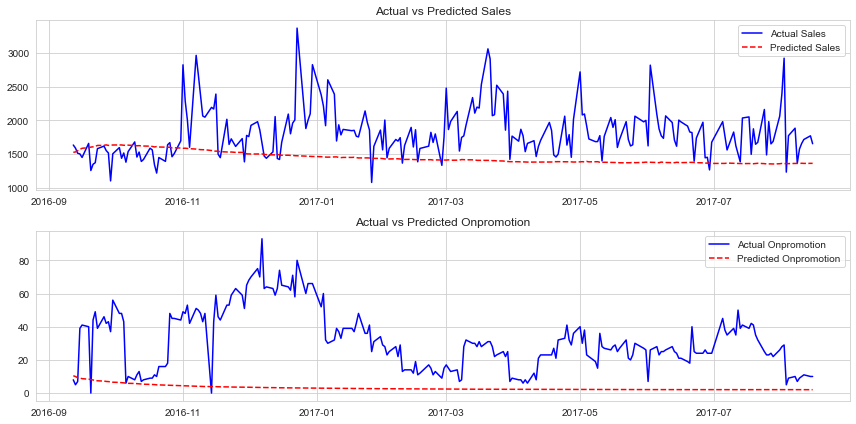

In [56]:
#plot prediction vs actual data
plt.figure(figsize=(12, 6))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog['sales'], label='Actual Sales', color='blue')
plt.plot(test_endog.index, test_preds['sales'], label='Predicted Sales', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Sales')
plt.legend()

# Plot Onpromotion (sudah dalam skala asli)
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog['onpromotion'], label='Actual Onpromotion', color='blue')
plt.plot(test_endog.index, test_preds['onpromotion'], label='Predicted Onpromotion', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Onpromotion')
plt.legend()

plt.tight_layout()
plt.show()